In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('../../../data/interim/up_cleaned_groundwater.csv')

In [3]:
numerical_columns = df.select_dtypes(include=np.number).columns 

numerical_columns

Index(['District LGD Code', 'Latitude', 'Longitude',
       'Groundwater Level Telemetry 6 Hourly (meter)'],
      dtype='object')

In [4]:
categorical_columns = df.select_dtypes(exclude=np.number).columns 

categorical_columns

Index(['Station', 'State', 'District', 'Data Acquisition Time'], dtype='object')

Now we will plot Histogram for these columns:

"Latitude", "Longitude", "Groundwater Level Telemetry Quadridaily (meter)"

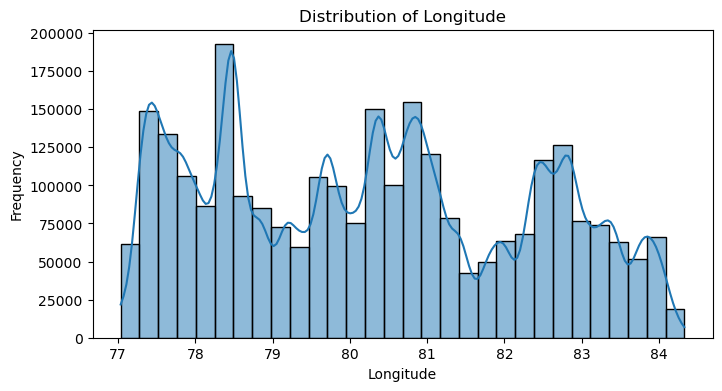

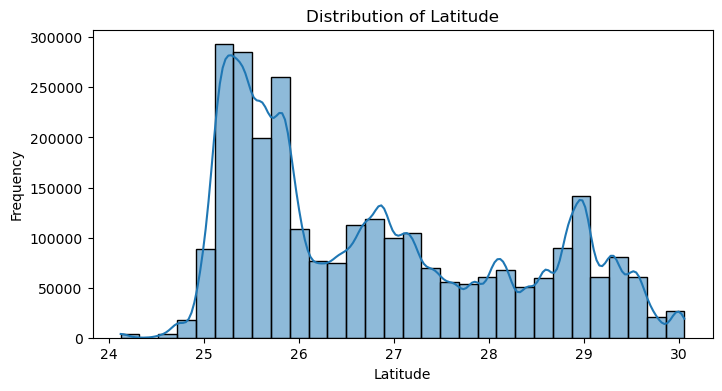

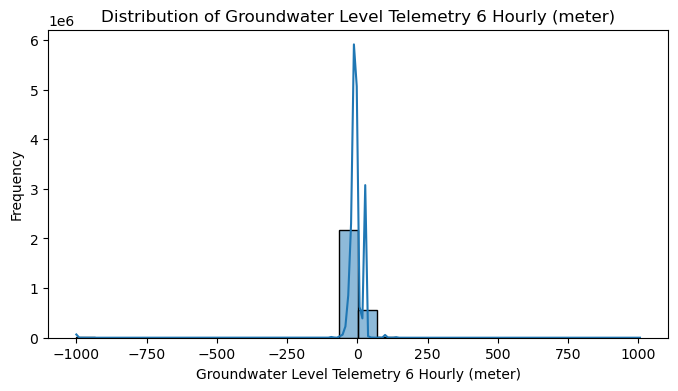

In [6]:
significant_columns = [
    'Longitude', 
    'Latitude', 
    'Groundwater Level Telemetry 6 Hourly (meter)'
] 

for col in significant_columns: 
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True) 

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

### Distribution of Longitude 

### Observation:
- The longitude values range approximately from **77.1° to 84.4°**, indicating that the monitoring stations are spread across the east-west extent of the study area.
- The distribution is **multimodal**, with several noticeable peaks instead of a single central peak, suggesting that stations are concentrated in multiple geographical clusters.
- The highest concentration of stations appears between **78°–81° longitude**, while comparatively fewer stations are located at the extreme eastern and western boundaries.
- No significant outliers or invalid longitude values are observed, indicating that the geographical coordinates are consistent with the expected study region.

### Insight:
The multimodal distribution reflects the uneven spatial placement of groundwater monitoring stations across different districts rather than a uniform geographic coverage.

### Distribution of Latitude 

### Observation:
- The latitude values range approximately from **24.0° to 30.0°**, covering the north-south extent of the study region.
- The distribution is **right-skewed and multimodal**, indicating that monitoring stations are concentrated in several latitude bands.
- A major concentration of stations is observed around **25°–26° latitude**, while smaller clusters are visible near **27°** and **29°**.
- Very few observations exist near the lower and upper latitude limits, suggesting sparse station coverage in those regions.
- No obvious invalid latitude values or extreme outliers are present.

### Insight:
The latitude distribution indicates that groundwater monitoring stations are unevenly distributed across the study area, with denser coverage in certain geographic zones and relatively sparse coverage toward the boundaries.

### Distribution of Groundwater Level Telemetry 6 Hourly (meter)

### Observation:
- Most groundwater level measurements are concentrated within a relatively narrow range around **0 meters**, indicating that the majority of observations fall within typical groundwater levels.
- The distribution is **highly peaked with long tails**, suggesting the presence of extreme values.
- A few observations extend to both large positive and large negative values (approximately **-1000 to +1000 meters**), which are highly unusual for groundwater measurements.
- These extreme values are likely to represent **outliers, sensor errors, missing value encodings, or data recording issues** rather than actual groundwater levels.

### Insight:
The groundwater level distribution is heavily influenced by extreme observations. These outliers should be investigated and appropriately handled during preprocessing to improve data quality and ensure reliable statistical analysis and machine learning model performance.

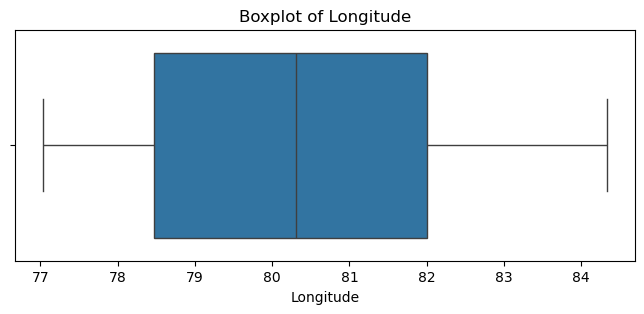

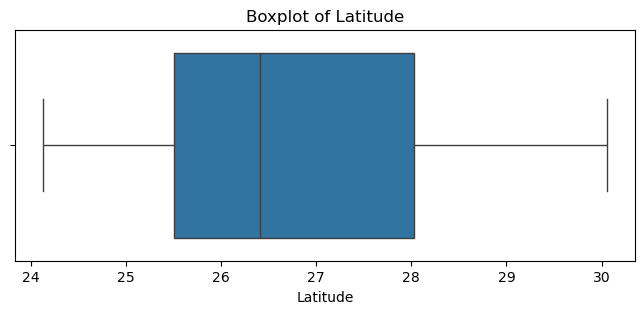

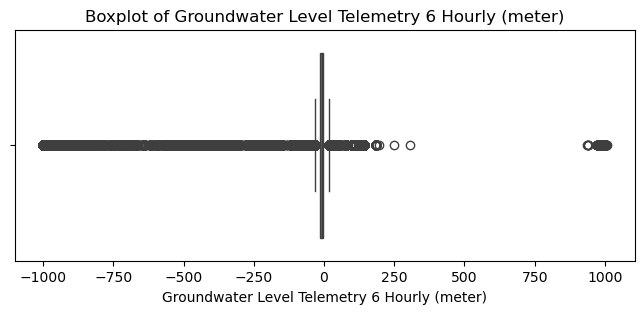

In [7]:
# now we will plot Boxplots for the same columns:  

for col in significant_columns: 
    plt.figure(figsize=(8,3)) 

    sns.boxplot(x=df[col]) 

    plt.title(f"Boxplot of {col}") 

    plt.show()

### Boxplot of Longitude

### Observation:
- The longitude values are distributed approximately between **77.0° and 84.3°**.
- The median longitude lies around **80.3°**, indicating the central east-west location of monitoring stations.
- The interquartile range (IQR) spans roughly from **78.5° to 82.0°**, showing that the middle 50% of stations are concentrated within this range.
- No significant outliers are observed beyond the whiskers, suggesting that all longitude values fall within the expected geographical boundaries.

### Insight:
The longitude values exhibit a well-distributed spatial coverage with no abnormal geographic coordinates, indicating good data quality for spatial analysis.

### Boxplot of Latitude

### Observation:
- The latitude values range approximately from **24.1° to 30.0°**.
- The median latitude is around **26.4°**, representing the central north-south location of the monitoring stations.
- The middle 50% of observations lie between approximately **25.5° and 28.1°**.
- No noticeable outliers are present, indicating that all monitoring stations are located within the expected geographical extent.

### Insight:
The latitude distribution is consistent and free from abnormal coordinate values, making it suitable for geographical visualization and spatial analysis.

### Boxplot of Groundwater Level Telemetry 6 Hourly (meter)

### Observation:
- The median groundwater level is close to **0 meters**, with the majority of observations concentrated within a relatively small range.
- The interquartile range (IQR) is very narrow, indicating that most groundwater measurements are clustered around the median.
- A large number of observations appear outside the whiskers on both the negative and positive sides, indicating the presence of numerous outliers.
- Some extreme values extend close to **-1000 meters** and **+1000 meters**, which are unrealistic for groundwater measurements and likely represent sensor errors, invalid readings, or incorrect data entries.

### Insight:
The groundwater level variable contains a substantial number of extreme values that dominate the visualization. These outliers should be carefully investigated and appropriately handled during preprocessing to improve the reliability of statistical analysis and machine learning models.

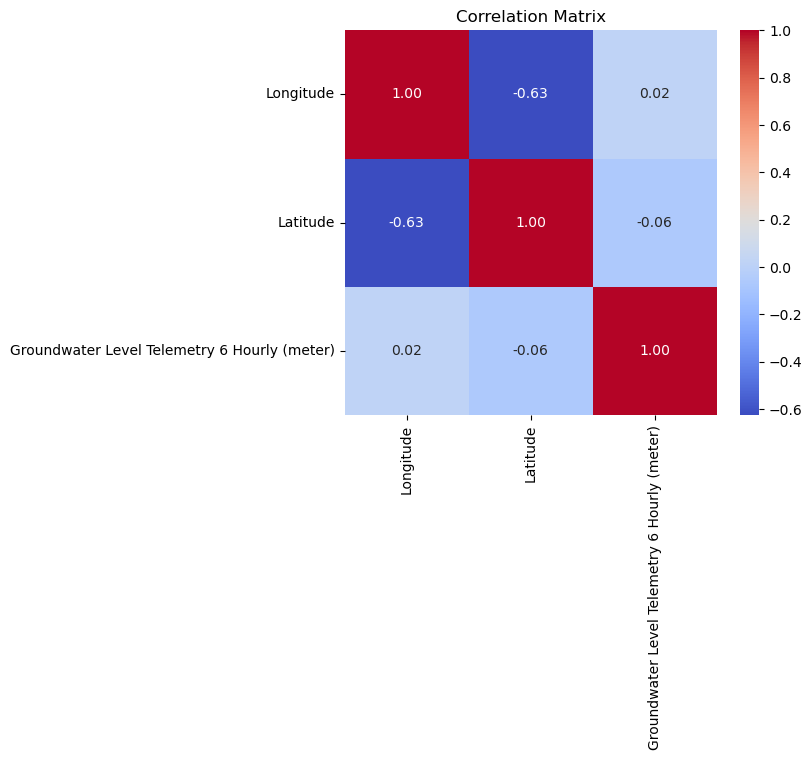

In [8]:
#now Heatmap for significant columns to see whether groundwater level has any linear relationship with location. 

corr = df[significant_columns].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation:
- The correlation heatmap shows the linear relationships among **Longitude**, **Latitude**, and **Groundwater Level Telemetry 6 Hourly (meter)**.
- **Longitude and Latitude** exhibit a **moderate negative correlation (-0.63)**, indicating that monitoring stations located further east generally tend to lie at relatively lower latitudes within the study area.
- **Groundwater Level** has **almost no correlation with Longitude (0.02)** and a **very weak negative correlation with Latitude (-0.06)**.
- The correlation coefficients between groundwater level and the geographical coordinates are close to zero, suggesting the absence of a strong linear relationship.

### Insight:
The results indicate that **geographical coordinates alone are not strong predictors of groundwater level**. Groundwater fluctuations are likely influenced more by factors such as rainfall, geology, aquifer characteristics, land use, seasonal variations, and temporal patterns rather than by latitude or longitude individually. The moderate negative correlation between latitude and longitude simply reflects the spatial arrangement of monitoring stations and does not imply any relationship with groundwater levels.

In [9]:
#now we will plot two scatter plots: 
#   (i) Latitude Vs Groundwater Level Telemetry Quadridaily (meter) 
#   (ii) Longitude Vs Groundwater Level Telemetry Quadridaily (meter)

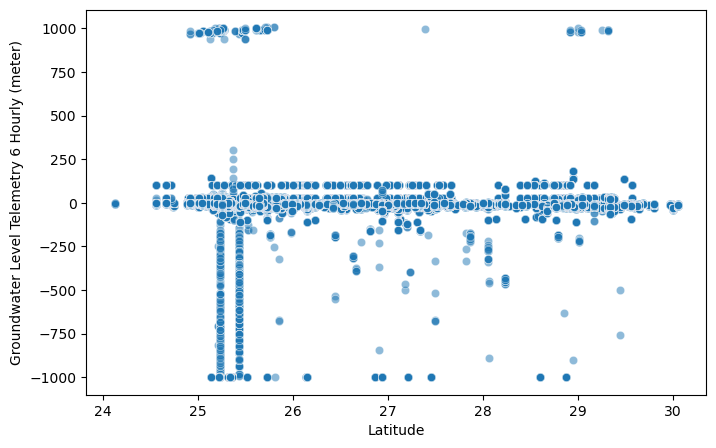

In [10]:
# (i) Latitude Vs Groundwater Level Telemetry Quadridaily (meter): 

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Latitude",
    y="Groundwater Level Telemetry 6 Hourly (meter)",
    alpha=0.5
)

plt.show()

### Observation:
- The scatter plot shows a wide dispersion of groundwater level measurements across all latitude values, with no clear increasing or decreasing trend.
- Most groundwater level observations are concentrated within a relatively narrow range around **0 meters**, regardless of latitude.
- Several extreme positive (around **1000 meters**) and negative (around **-1000 meters**) values are visible across different latitude ranges, indicating the presence of significant outliers.
- A noticeable vertical concentration of points is observed around **25.2°–25.5° latitude**, suggesting that a large number of measurements were collected from stations located within this latitude band.
- The data points are widely scattered, and no distinct linear relationship between latitude and groundwater level is evident.

### Insight:
The scatter plot indicates that **latitude alone has little influence on groundwater level**, which is consistent with the very weak correlation coefficient (**r = -0.06**) observed in the correlation analysis. The groundwater level appears to be influenced more by local hydrogeological conditions, seasonal variations, rainfall, aquifer characteristics, and temporal factors than by geographic latitude alone. The presence of several extreme outliers also suggests that further investigation of these observations is necessary before model development.

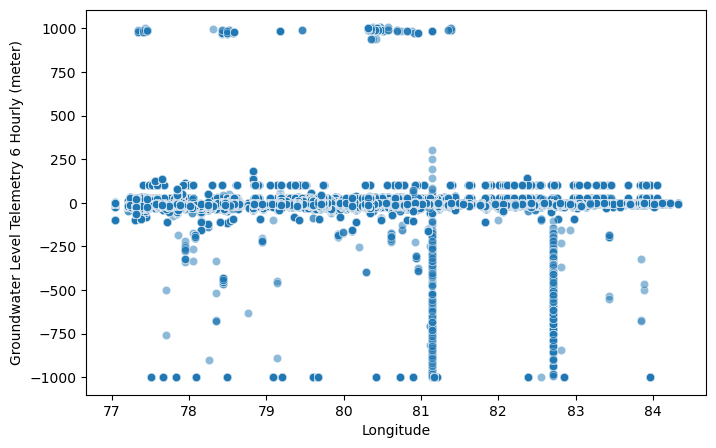

In [11]:
# (ii) Longitude Vs Groundwater Level Telemetry Quadridaily (meter)

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Groundwater Level Telemetry 6 Hourly (meter)",
    alpha=0.5
)

plt.show()

### Observation:
- The scatter plot shows a wide dispersion of groundwater level measurements across the entire longitude range, with no clear increasing or decreasing trend.
- Most groundwater level observations are concentrated around **0 meters**, irrespective of longitude.
- Several extreme positive (approximately **1000 meters**) and negative (approximately **-1000 meters**) values are present throughout the longitude range, indicating the presence of significant outliers.
- Dense vertical bands are visible around **81.1°** and **82.7° longitude**, suggesting that a large number of groundwater measurements were recorded from monitoring stations located at these longitudes.
- The points are randomly scattered, indicating the absence of any strong linear relationship between longitude and groundwater level.

### Insight:
The scatter plot suggests that **longitude alone has little influence on groundwater level**, which is supported by the near-zero correlation coefficient (**r = 0.02**) observed in the correlation analysis. Groundwater levels are more likely influenced by factors such as rainfall, aquifer properties, geological conditions, seasonal variations, and temporal changes rather than geographic longitude alone. The presence of numerous extreme outliers further highlights the need for careful outlier assessment before model development.